# Задача 2. Классификация состояния квартиры по тексту объявления

## 1. Постановка задачи

Мы работаем с платформой недвижимости Домклик. На таких площадках
карточку объявления заполняет сам продавец, поэтому зачастую мы имеем не полную информацию.
Зато текст описания люди пишут всегда довольно подробно (медиана около 1350 символов), 
и состояние квартиры можно хорошо отследть по нему.

Отсюда наша вторая задача: научиться по одному тексту описания определять состояние квартиры,
то есть класс ремонта (дизайнерский, евро, косметический, требует ремонта, без ремонта). Это нужно
сразу для трёх вещей:

1. автозаполнять пустое поле «Ремонт», чтобы каталог был полнее и фильтры поиска работали честно;
2. ловить расхождения между тем, что заявил продавец, и тем, что реально написано в тексте, и
   отправлять такие объявления на модерацию;
3. отдавать восстановленное состояние квартиры в оценщик цены из первой задачи: ремонт это один из
   заметных факторов цены, и когда поле пустое или враньё, оценка плывёт.

План такой: вторая модель приводит в порядок вход (чинит и проверяет признаки, спрятанные
в неструктурированном тексте), а первая по этому входу считает цену

На языке машинного обучения это многоклассовая классификация текста: 5 классов, русскоязычные
описания. Качество смотрим по accuracy и macro-F1. Macro-F1 здесь важен отдельно: классы
несбалансированы, а пропустить редкие «требует ремонта» и «без ремонта» опаснее всего, потому что
именно на них покупателя проще всего ввести в заблуждение.

Дальше сравниваем пять заметно разных нейросетевых архитектур на одних и тех же данных, по
нарастающей сложности: простой бейзлайн на усреднении эмбеддингов слов, затем TextCNN (свёртки, Kim 2014),
BiLSTM сattention, замороженный ruBERT-tiny2 с MLP-головой и, наконец, дообучаемый ruBERT-tiny2. 
Последние две модели опираются на предобученный трансформер, которых
в лекциях не было. 

Все запуски пишем в MLflow: метрики по эпохам плюс артефакты, чтобы потом можно
было воспроизвести предсказания без повторного обучения.


## 2. Окружение

In [1]:
!pip install -q torch mlflow transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 113.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 936.9/936.9 kB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os, re, json, copy, random, time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import mlflow
import joblib

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
seed_everything()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

DATA_PATH = 'data (6).csv'

mlflow.set_experiment('moscow-flats-text-repair')


device: cuda


2026/06/15 19:10:27 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/15 19:10:27 INFO mlflow.store.db.utils: Updating database tables
2026/06/15 19:10:29 INFO mlflow.tracking.fluent: Experiment with name 'moscow-flats-text-repair' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1781550629088, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781550629088, lifecycle_stage='active', name='moscow-flats-text-repair', tags={}, trace_location=None, workspace='default'>

## 3. Данные: тексты, метки и три источника утечки

Используется тот же датасет объявлений. Здесь берём только нужные
колонки: «Описание» (текст), «Ремонт» (метка), «Адрес» (группа для сплита),
«Цена»/«Площадь» (для бизнес-инсайтов).

Метки. Поле «Ремонт» содержит 19 сырых значений с дублями по регистру и синонимами -
сводим к 5 классам; маргинальные значения про отделку новостроек (<40 объектов) исключаем как другую сущность.

Перед обучением закрываем три источника утечки/тривиальности - каждый проверен на данных:

1. Дубли текстов (835 точных дублей: застройщики копируют описание для всех квартир корпуса);
   301 дубль пересекал бы train/test даже при групповом сплите, поэтому дедуплицируем по тексту.
2. Утечка через ЖК: квартиры одного дома имеют похожие описания, поэтому, как и в задаче 1,
   GroupShuffleSplit по адресу.
3. Прямое упоминание метки в тексте («дизайнерский ремонт» написан в 43% описаний своего
   класса), поэтому маскируем ремонто-специфичные формулировки токеном `маска`. Это превращает задачу
   из поиска ключевого слова в понимание контекста (паркет, мрамор, «заезжай и живи», «под себя»…).
   Влияние маскирования измерим явно - это отдельный инсайт.

In [ ]:
#числа в русской локали: 1 234,5 м2 превращаем в 1234.5
def num_ru(s: pd.Series) -> pd.Series:
    s = s.astype(str)
    for ch in ['\u00a0', 'м²', 'м2', '%', ' ']:
        s = s.str.replace(ch, '', regex=False)
    s = s.str.replace(',', '.', regex=False)
    return pd.to_numeric(s, errors='coerce')

raw = pd.read_csv(DATA_PATH, sep=';', quotechar='"', engine='python', on_bad_lines='skip')
#в файле повторяются строки-заголовки (csv склеен из кусков) - выкидываем их
raw = raw[raw['Адрес'].astype(str).str.strip() != 'Адрес'].reset_index(drop=True)

df = pd.DataFrame()
df['price'] = pd.to_numeric(raw['Цена'], errors='coerce')
df['area_total'] = num_ru(raw['Площадь'])
df['repair_raw'] = (raw['Ремонт'].astype('string').str.strip().str.lower().replace({'евроремонт': 'евро'}))

#из адреса делаем группу для сплита (первые два уровня: город/улица), чтобы дом не утёк в test
addr = (raw['Адрес'].astype(str).str.replace('\u00a0', ' ', regex=False)
        .str.replace(r'\s+', ' ', regex=True).str.strip())
df['addr_group'] = addr.str.split(',').str[:2].str.join(',').str.lower()
df['description'] = (raw['Описание'].fillna('').astype(str)
                     .str.replace(r'\s+', ' ', regex=True).str.strip())

#сырое поле "Ремонт" - это 19 значений с дублями по регистру и синонимами.
#сводим к 5 классам; редкие значения про отделку новостроек (<40 шт) считаем
#отдельной сущностью и выкидываем
CANON = {
    'дизайнерский': 'дизайнерский', 'дизайнерский ремонт': 'дизайнерский', 'авторский проект': 'дизайнерский',
    'евро': 'евро', 'под ключ': 'евро',
    'косметический': 'косметический', 'хороший': 'косметический', 'среднее': 'косметический',
    'требует ремонта': 'требует ремонта',
    'без ремонта': 'без ремонта', 'отсутствует': 'без ремонта', 'стройвариант': 'без ремонта',
    'под чистовой ремонт': 'без ремонта', 'чистовая': 'без ремонта',
}
df['label'] = df['repair_raw'].map(lambda x: CANON.get(x) if pd.notna(x) else None)

#слишком короткие описания (< 100 симв.) почти не несут смысла - отбрасываем
labeled = df[df['label'].notna() & (df['description'].str.len() >= 100)].copy()
unlabeled = df[df['label'].isna() & (df['description'].str.len() >= 100)].copy()  #кандидаты на автозаполнение

n0 = len(labeled)
labeled = labeled.drop_duplicates(subset='description').reset_index(drop=True)

print(f'размечено: было {n0}, стало {len(labeled)} после дедупликации текстов; '
      f'неразмеченных (кандидаты на автозаполнение): {len(unlabeled)}')

labeled['label'].value_counts()


размечено: 2839 -> 2788 после дедупликации текстов; неразмеченных (кандидаты на автозаполнение): 72


,count
label,
косметический,827
евро,726
дизайнерский,565
без ремонта,379
требует ремонта,291


In [5]:
#в описаниях продавцы часто прямо пишут класс ("дизайнерский ремонт") - это утечка
#метки в текст. Маскируем такие формулировки токеном "маска", чтобы модель училась
#по контексту, а не искала ключевое слово
MASK_RE = (r'(?:дизайнерск\w+|авторск\w+|евро[- ]?ремонт\w*|косметическ\w+|'
           r'капитальн\w+\s+ремонт\w*|требует\w*\s+ремонт\w*|под ремонт|'
           r'без ремонта|без отделки|черновая отделка|черновой)')

def prepare_text(s: pd.Series, mask=True) -> pd.Series:
    t = s.str.lower()
    if mask:
        t = t.str.replace(MASK_RE, ' маска ', regex=True)
    return t

labeled['text'] = prepare_text(labeled['description'])

#на всякий случай проверим, что прямых упоминаний классов не осталось
for cls, pat in [('дизайнерский', r'дизайнерск'), ('евро', r'евро[- ]?ремонт'),
                 ('косметический', r'косметическ'), ('без ремонта', r'без ремонта')]:
    share = labeled.loc[labeled['label'] == cls, 'text'].str.contains(pat).mean()
    assert share == 0.0, cls
print('маскирование ок: прямых упоминаний классов в текстах не осталось')


маскирование ок: прямых упоминаний классов в текстах не осталось


In [ ]:
#групповой сплит 70/15/15 по адресу. Сначала отрезаем 30% (val+test), потом делим пополам
y_str = labeled['label'].values
groups = labeled['addr_group'].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
idx_tr, rest = next(gss.split(np.arange(len(labeled)).reshape(-1, 1), y_str, groups))
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
va_i, te_i = next(gss2.split(rest.reshape(-1, 1), y_str[rest], groups[rest]))
idx_va, idx_te = rest[va_i], rest[te_i]

print(f'train={len(idx_tr)}  val={len(idx_va)}  test={len(idx_te)}')

le = LabelEncoder().fit(y_str[idx_tr])
CLASSES = list(le.classes_)
y = le.transform(y_str)
print('классы:', CLASSES)

def clf_metrics(y_true, y_pred):
    return {'accuracy': float(accuracy_score(y_true, y_pred)),
            'macro_f1': float(f1_score(y_true, y_pred, average='macro'))}


train=1701  val=591  test=496
классы: ['без ремонта', 'дизайнерский', 'евро', 'косметический', 'требует ремонта']


## 4. EDA текстов

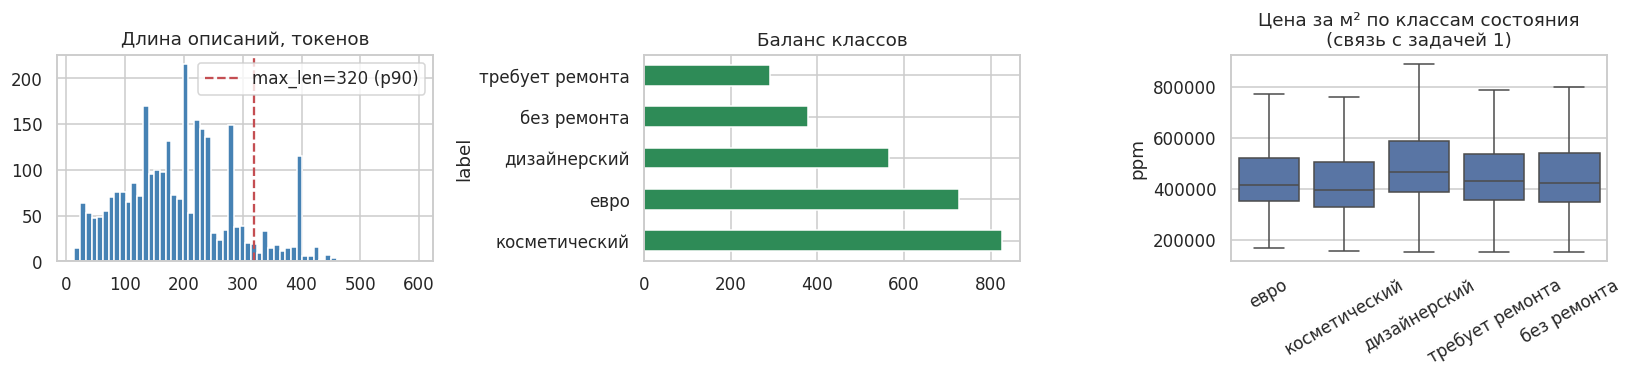

медианная длина 189 токенов, p90 = 323


In [ ]:
tok_len = labeled['text'].str.findall(r'[а-яёa-z0-9]+').str.len()

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].hist(tok_len, bins=60, color='steelblue')
axes[0].axvline(320, color='r', ls='--', label='max_len=320 (p90)')
axes[0].set_title('Длина описаний, токенов')
axes[0].legend()

labeled['label'].value_counts().plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Баланс классов')

sns.boxplot(data=labeled.assign(ppm=labeled['price'] / labeled['area_total']), x='label', y='ppm', ax=axes[2], showfliers=False)

axes[2].set_title('Цена за м² по классам состояния')
axes[2].tick_params(axis='x', rotation=30)
plt.show()

print(f'медианная длина {int(tok_len.median())} токенов, p90 = {int(tok_len.quantile(0.9))}')


Классы умеренно несбалансированы (от ±950 «требует ремонта» до ±2200 «косметический») -
используем взвешенный лосс и macro-F1. Цена за м² монотонно связана с классом состояния -
прямое подтверждение ценности этого признака для оценщика из задачи 1.

In [ ]:
#смотрим, какие слова отличают классы - чистая статистика частот, без модели.
#Метрика: лог-отношение "доля документов класса со словом" к "доле в остальных".
TOKEN_RE = re.compile(r'[а-яёa-z0-9]+')
def tokenize(s):
    return TOKEN_RE.findall(s)

def class_word_counts(cls):
    cnt = Counter()
    for t in labeled.loc[labeled['label'] == cls, 'text'].iloc[:3000]:
        cnt.update(set(tokenize(t)))   #set, значит считаем по документам, а не по вхождениям
    return cnt

per_cls, all_cnt = {}, Counter()
for cls in labeled['label'].dropna().unique():
    per_cls[cls] = class_word_counts(cls)
    all_cnt.update(per_cls[cls])

n_cls = {cls: (labeled['label'] == cls).sum() for cls in per_cls}
for cls, cnt in per_cls.items():
    #+1 в знаменателе - сглаживание, чтобы редкое слово не дало бесконечный скор
    scores = {w: (c / n_cls[cls]) / ((all_cnt[w] - c + 1) / (len(labeled) - n_cls[cls]))
              for w, c in cnt.items() if all_cnt[w] >= 30}
    top = sorted(scores, key=scores.get, reverse=True)[:10]
    print(f'{cls:>16}: {", ".join(top)}')


            евро: ухоженная, качественным, качественный, делали, встроенная, бытовая, альтернативная, стоимости, посудомоечная, сделан
   косметический: застекленный, хорошие, панельного, хорошее, распашонка, пассажирским, альтернатива, застекленная, спальном, любую
    дизайнерский: стильная, душевой, кровать, постирочная, мелочей, натурального, качества, диван, столовая, укомплектована
 требует ремонта: митино, пятницкое, соседству, парках, воплотить, гулять, идеи, машиномест, отсюда, трёх
     без ремонта: идеи, обустроить, сдан, вкусу, своему, воплотить, санузлы, отделки, мечты, реализовать


Различительная лексика осмысленна даже после маскирования (материалы, мебель, формулировки
про состояние) - сигнал распределён по контексту, значит, у моделей, понимающих сочетания и
порядок слов, есть пространство для выигрыша над простым усреднением.

## 5. Токенизация для собственных архитектур

Для собственных архитектур (TextCNN, BiLSTM) - словная токенизация со словарём по train (частота >= 3, ±15 тыс. слов), паддинг/обрезка до `MAX_LEN = 320` (покрывает 90% текстов).
Индекс 0 - паддинг, 1 - неизвестное слово. Для трансформера используется его собственныйтокенизатор

In [ ]:
MAX_LEN = 320

#словарь слово-индекс по train. 0 это паддинг, 1 это неизвестное слово
class WordVocab:
    def __init__(self, texts, min_freq=3):
        cnt = Counter()
        for t in texts:
            cnt.update(tokenize(t))
        
        #оставляем слова с частотой >= 3, иначе словарь раздувается опечатками
        self.itos = ['<pad>', '<unk>'] + [w for w, c in cnt.most_common() if c >= min_freq]
        self.stoi = {w: i for i, w in enumerate(self.itos)}

    def encode(self, text, max_len=MAX_LEN):
        ids = [self.stoi.get(w, 1) for w in tokenize(text)][:max_len]
        return ids + [0] * (max_len - len(ids))   #добиваем паддингом до max_len

    def __len__(self):
        return len(self.itos)

vocab = WordVocab(labeled['text'].iloc[idx_tr])   #строим только по train
print('размер словаря:', len(vocab))

ids_all = torch.tensor(np.stack([vocab.encode(t) for t in labeled['text']]), dtype=torch.long)
y_t = torch.tensor(y, dtype=torch.long)
print('тензор токенов:', tuple(ids_all.shape))


## 6. Архитектуры: бейзлайн на усреднении эмбеддингов, TextCNN и BiLSTM + attention

Бейзлайн на усреднении эмбеддингов (класс `MeanEmbeddingBaseline`): просто усредняем обучаемые эмбеддингивсех слов и сверху ставим линейный слой. Это самая примитивная нейросеть для текста, она полностью игнорирует порядок слов, никаких свёрток и рекуррентности тут нет. Нужна как точка отсчёта:
всё, что более сложные архитектуры выигрывают у неё, и есть вклад структуры текста, а не просто набора слов.

TextCNN (Kim, 2014): параллельные 1-D свёртки с окнами 2/3/4/5 слов над матрицей эмбеддингов и global max-pooling. По сути детектор локальных фраз-индикаторов («натяжные потолки», «требуется замена»)

BiLSTM + additive attention: двунаправленная LSTM читает текст целиком, attention-пулинг взвешивает скрытые сотояния. Это модель порядка слов и дальних зависимостей, а attention заодно даёт интерпретируемость, т.к., какие слова повлияли на решение.


In [ ]:
#простой бейзлайн: усредняем эмбеддинги слов и сверху линейный слой. Порядок слов полностью
#игнорируется (никаких свёрток/рекуррентности)
class MeanEmbeddingBaseline(nn.Module):
    def __init__(self, vocab_size, n_classes, d_emb=128, dropout=0.2):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d_emb, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_emb, n_classes)

    def forward(self, ids):
        mask = (ids != 0).unsqueeze(-1).float()
        e = self.emb(ids)
        mean = (e * mask).sum(1) / mask.sum(1).clamp(min=1.0)
        return self.fc(self.dropout(mean))


#Kim 2014: параллельные свёртки с окнами 2/3/4/5 слов и max-pooling.
#По сути детектор локальных фраз-индикаторов ("натяжные потолки", "требуется замена")
class TextCNN(nn.Module):
    def __init__(self, vocab_size, n_classes, d_emb=128, n_filters=128, kernel_sizes=(2, 3, 4, 5), dropout=0.5):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d_emb, padding_idx=0)
        self.convs = nn.ModuleList([nn.Conv1d(d_emb, n_filters, k, padding=k // 2) for k in kernel_sizes])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(n_filters * len(kernel_sizes), n_classes)

    def forward(self, ids):
        x = self.emb(ids).transpose(1, 2)
        feats = [torch.relu(c(x)).max(dim=2).values for c in self.convs]
        return self.fc(self.dropout(torch.cat(feats, dim=1)))


#Двунаправленная LSTM с attention-пулингом. В отличие от CNN читает текст целиком и ловит
#дальние зависимости, а attention заодно показывает, какие слова повлияли на ответ
class BiLSTMAttn(nn.Module):
    def __init__(self, vocab_size, n_classes, d_emb=128, d_hidden=128, n_layers=1, dropout=0.3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d_emb, padding_idx=0)
        self.lstm = nn.LSTM(d_emb, d_hidden, num_layers=n_layers, batch_first=True, bidirectional=True, dropout=dropout if n_layers > 1 else 0.0)
        
        self.attn = nn.Linear(2 * d_hidden, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(2 * d_hidden, n_classes)

    def forward(self, ids):
        mask = (ids != 0)
        h, _ = self.lstm(self.emb(ids))
        scores = self.attn(h).squeeze(-1)
        scores = scores.masked_fill(~mask, -1e9)
        w = torch.softmax(scores, dim=1).unsqueeze(-1)
        pooled = (h * w).sum(dim=1)
        return self.fc(self.dropout(pooled))


## 7. Архитектуры 3-4: предобученный трансформер ruBERT-tiny2

[`cointegrated/rubert-tiny2`](https://huggingface.co/cointegrated/rubert-tiny2) - русскоязычный BERT библиотека HuggingFace `transformers`

Два принципиально разных режима использования - их сравнение само по себе содержательный вывод:
- (3) frozen: BERT заморожен и используется как экстрактор признаков (mean-pooling скрытых состояний даёт вектор 312), сверху обучается только MLP-голова. Дёшево, эмбеддинги считаются один раз;
- (4) fine-tuning: дообучаются все веса BERT под задачу (малый lr = 2e-5, linear warmup, 3-6 эпох) - дороже, но модель адаптирует само представление языка под доменную лексику объявлений.

In [ ]:
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification

BERT_NAME = 'cointegrated/rubert-tiny2'
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)

def bert_encode(texts, max_len=MAX_LEN):
    enc = bert_tokenizer(list(texts), padding='max_length', truncation=True, max_length=max_len, return_tensors='pt')
    
    return enc['input_ids'], enc['attention_mask']

bert_ids, bert_mask = bert_encode(labeled['text'])
print('BERT-токены:', tuple(bert_ids.shape))


#mean-pooling замороженного BERT. Считаем один раз, дальше учим только голову, поэтому быстро
@torch.no_grad()
def bert_frozen_embeddings(ids, mask, batch_size=64):
    bert = AutoModel.from_pretrained(BERT_NAME).to(DEVICE).eval()
    out = []
    for i in range(0, len(ids), batch_size):
        b_ids = ids[i:i + batch_size].to(DEVICE)
        b_mask = mask[i:i + batch_size].to(DEVICE)
        h = bert(input_ids=b_ids, attention_mask=b_mask).last_hidden_state
        
        m = b_mask.unsqueeze(-1).float()
        out.append(((h * m).sum(1) / m.sum(1)).cpu())
        
    del bert
    
    torch.cuda.empty_cache()
    return torch.cat(out)

frozen_emb = bert_frozen_embeddings(bert_ids, bert_mask)
print('frozen-эмбеддинги:', tuple(frozen_emb.shape))


#голова поверх замороженных эмбеддингов BERT. BERT тут просто экстрактор признаков
class FrozenBertMLP(nn.Module):
    def __init__(self, d_in, n_classes, hidden=(256, 128), dropout=0.3):
        super().__init__()
        layers, d = [], d_in
        for h in hidden:
            layers += [nn.Linear(d, h), nn.GELU(), nn.Dropout(dropout)]
            d = h
            
        self.net = nn.Sequential(*layers, nn.Linear(d, n_classes))

    def forward(self, emb):
        return self.net(emb)


#дообучаем весь BERT под задачу. Дороже, зато представление адаптируется под домен
class BertFineTune(nn.Module):
    def __init__(self, n_classes, model_name=BERT_NAME):
        super().__init__()
        self.bert = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=n_classes)

    def forward(self, ids, mask):
        return self.bert(input_ids=ids, attention_mask=mask).logits


## 8. Единый цикл обучения с логированием в MLflow

Один цикл для всех архитектур (честное сравнение). Датасет любой архитектуры - кортеж входных
тензоров + метка, модель вызывается как `model(*inputs)`.

- лосс - взвешенная кросс-энтропия (веса обратны частотам классов в train);
- AdamW; scheduler - linear warmup и затем linear decay (стандарт для трансформеров, не вредит остальным);
- ранняя остановка по val macro-F1 с восстановлением лучших весов;
- в MLflow: параметры архитектуры/обучения, train/val accuracy и macro-F1 по эпохам, финальные
  метрики на test, артефакты (`model_state.pt`, `config.json`, `label_encoder.joblib` +
  словарь/токенизатор) - для воспроизведения предсказаний без переобучения (раздел 11).

In [ ]:
from dataclasses import dataclass, asdict
from tqdm.auto import tqdm

@dataclass
class TextExpConfig:
    name: str
    arch: str
    lr: float = 1e-3
    weight_decay: float = 1e-4
    batch_size: int = 64
    max_epochs: int = 30
    patience: int = 5
    warmup_frac: float = 0.1
    dropout: float = 0.3
    select_metric: str = 'macro_f1'
    class_weights: bool = True
    extra: dict = None

def build_model_and_data(cfg, n_classes, vocab_obj=None, inputs_override=None):
    v = vocab_obj if vocab_obj is not None else vocab
    if cfg.arch == 'mean_emb':
        model = MeanEmbeddingBaseline(len(v), n_classes, dropout=cfg.dropout, **(cfg.extra or {}))
        inputs, tok_art = (ids_all,), ('vocab.joblib', v)
    elif cfg.arch == 'cnn':
        model = TextCNN(len(v), n_classes, dropout=cfg.dropout, **(cfg.extra or {}))
        inputs, tok_art = (ids_all,), ('vocab.joblib', v)
    elif cfg.arch == 'bilstm':
        model = BiLSTMAttn(len(v), n_classes, dropout=cfg.dropout, **(cfg.extra or {}))
        inputs, tok_art = (ids_all,), ('vocab.joblib', v)
    elif cfg.arch == 'bert_frozen':
        model = FrozenBertMLP(frozen_emb.shape[1], n_classes, dropout=cfg.dropout)
        inputs, tok_art = (frozen_emb,), ('bert_tokenizer', None)
    elif cfg.arch == 'bert_finetune':
        model = BertFineTune(n_classes, **(cfg.extra or {}))
        inputs, tok_art = (bert_ids, bert_mask), ('bert_tokenizer', None)
    if inputs_override is not None:
        inputs = inputs_override
    return model.to(DEVICE), inputs, tok_art


@torch.no_grad()
def predict_logits(model, inputs, idx, batch_size=256):
    model.eval()
    out = []
    for i in range(0, len(idx), batch_size):
        sl = idx[i:i + batch_size]
        out.append(model(*[t[sl].to(DEVICE) for t in inputs]).cpu())
    return torch.cat(out)


#один и тот же цикл обучения для всех архитектур, так сравнение честное.
#переопределяемые аргументы (y_enc/le_obj/vocab_obj и т.д.) нужны продуктовой части:
#там другая разметка (3 класса) и другая токенизация (немаскированный текст)
def train_text_config(cfg: TextExpConfig, verbose=True, y_enc=None, le_obj=None, vocab_obj=None, inputs_override=None, idx_tr_override=None):
    y = y if y_enc is None else y_enc
    le = le if le_obj is None else le_obj
    idx_tr = idx_tr if idx_tr_override is None else idx_tr_override
    n_classes = len(le.classes_)

    seed_everything(SEED)
    model, inputs, (tok_name, tok_obj) = build_model_and_data(
        cfg, n_classes, vocab_obj=vocab_obj, inputs_override=inputs_override)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    y_t = torch.tensor(y, dtype=torch.long)
    train_ds = TensorDataset(*[t[idx_tr] for t in inputs], y_t[idx_tr])
    loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)

    if cfg.class_weights:
        counts = np.bincount(y[idx_tr], minlength=n_classes)
        weights = torch.tensor(len(idx_tr) / (n_classes * counts), dtype=torch.float32).to(DEVICE)
        loss_fn = nn.CrossEntropyLoss(weight=weights)
    else:
        loss_fn = nn.CrossEntropyLoss()

    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    total_steps = cfg.max_epochs * len(loader)
    warmup = max(1, int(cfg.warmup_frac * total_steps))
    
    #linear warmup, затем linear decay (стандарт для трансформеров, остальным не вредит)
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: s / warmup if s < warmup else max(0.0, (total_steps - s) / max(1, total_steps - warmup)))

    history = {'train_f1': [], 'val_f1': []}
    best_score, best_state, best_epoch, bad = -1.0, None, 0, 0
    t0 = time.time()

    with mlflow.start_run(run_name=cfg.name):
        mlflow.log_params({**{k: v for k, v in asdict(cfg).items() if k != 'extra'},
                           **(cfg.extra or {}), 'n_params': n_params,
                           'classes': ','.join(le.classes_), 'masking': True,
                           'split': 'group_by_address', 'max_len': MAX_LEN})

        for epoch in range(cfg.max_epochs):
            model.train()
            for batch in tqdm(loader, desc=f'epoch {epoch}', leave=False):
                *xb, yb = [t.to(DEVICE) for t in batch]
                opt.zero_grad()
                loss = loss_fn(model(*xb), yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                sched.step()

            #метрики на train и val после каждой эпохи, логируем их по эпохам
            m_tr = clf_metrics(y[idx_tr], predict_logits(model, inputs, idx_tr).argmax(1).numpy())
            m_va = clf_metrics(y[idx_va], predict_logits(model, inputs, idx_va).argmax(1).numpy())
            history['train_f1'].append(m_tr['macro_f1'])
            history['val_f1'].append(m_va['macro_f1'])
            mlflow.log_metrics({'train_macro_f1': m_tr['macro_f1'], 'train_acc': m_tr['accuracy'],
                                'val_macro_f1': m_va['macro_f1'], 'val_acc': m_va['accuracy']},
                               step=epoch)

            #ранняя остановка с сохранением лучших весов
            score = m_va[cfg.select_metric]
            if score > best_score + 1e-4:
                best_score, best_epoch, bad = score, epoch, 0
                best_state = copy.deepcopy(model.state_dict())
            else:
                bad += 1
                if bad >= cfg.patience:
                    break

            if verbose:
                print(f'  [{cfg.name}] epoch {epoch:2d} | train F1 {m_tr["macro_f1"]:.3f} '
                      f'| val F1 {m_va["macro_f1"]:.3f}')

        model.load_state_dict(best_state)   #откатываемся на лучшую эпоху
        logits_te = predict_logits(model, inputs, idx_te)
        m_te = clf_metrics(y[idx_te], logits_te.argmax(1).numpy())
        m_va = clf_metrics(y[idx_va], predict_logits(model, inputs, idx_va).argmax(1).numpy())
        mlflow.log_metrics({**{f'best_val_{k}': v for k, v in m_va.items()},
                            **{f'test_{k}': v for k, v in m_te.items()},
                            'best_epoch': best_epoch, 'train_time_s': time.time() - t0})

        #--- сохраняем артефакты, чтобы потом воспроизвести предсказания без переобучения ---
        os.makedirs('artifacts_tmp', exist_ok=True)
        torch.save(best_state, 'artifacts_tmp/model_state.pt')
        with open('artifacts_tmp/config.json', 'w') as f:
            json.dump({k: v for k, v in asdict(cfg).items()}, f, ensure_ascii=False, indent=2)
        joblib.dump(le, 'artifacts_tmp/label_encoder.joblib')
        arts = ['model_state.pt', 'config.json', 'label_encoder.joblib']
        if tok_name == 'vocab.joblib':
            joblib.dump(tok_obj, 'artifacts_tmp/vocab.joblib')
            arts.append('vocab.joblib')
        for fn in arts:
            mlflow.log_artifact(f'artifacts_tmp/{fn}')
        if tok_name == 'bert_tokenizer':
            bert_tokenizer.save_pretrained('artifacts_tmp/bert_tokenizer')
            mlflow.log_artifacts('artifacts_tmp/bert_tokenizer', artifact_path='bert_tokenizer')
        run_id = mlflow.active_run().info.run_id

    print(f'[{cfg.name}] best epoch {best_epoch}, params {n_params:,} | '
          f'TEST: acc={m_te["accuracy"]:.3f}, macro-F1={m_te["macro_f1"]:.3f}')
    
    return {
        'config': cfg,
        'model': model,
        'inputs': inputs,
        'history': history,
        'val': m_va,
        'test': m_te,
        'logits_te': logits_te,
        'logits_va': predict_logits(model, inputs, idx_va),
        'run_id': run_id, 'n_params': n_params
    }


## 9. Запуск сравнения архитектур

Гиперпараметры: lr для своих архитектур 1e-3 (стандарт для обучения с нуля), для fine-tuning
BERT - 3e-5 при 15 эпохах с patience 4: на пробном запуске с 8 эпохами val-F1 рос до последней
эпохи - модель была недообучена, поэтому бюджет эпох увеличен (вывод о подборе гиперпараметров).
Batch size 64 (для fine-tuning - 32, ограничение памяти). Dropout у TextCNN выше (0.5, как в
оригинальной статье Kim 2014) - у модели с max-pooling это основная регуляризация.

In [ ]:
TEXT_CONFIGS = [
    TextExpConfig(name='0_mean_emb_baseline', arch='mean_emb', lr=2e-3, dropout=0.2,
                  extra={'d_emb': 128}),
    TextExpConfig(name='1_textcnn', arch='cnn', lr=1e-3, dropout=0.5,
                  extra={'d_emb': 128, 'n_filters': 128, 'kernel_sizes': (2, 3, 4, 5)}),
    TextExpConfig(name='2_bilstm_attn', arch='bilstm', lr=1e-3, dropout=0.3,
                  extra={'d_emb': 128, 'd_hidden': 128}),
    TextExpConfig(name='3_rubert_frozen_mlp', arch='bert_frozen', lr=1e-3, dropout=0.3,
                  max_epochs=40, patience=6),
    #fine-tune: малый lr, эпох побольше, на пробном запуске с 8 эпохами модель недоучивалась
    TextExpConfig(name='4_rubert_finetune', arch='bert_finetune', lr=3e-5,
                  batch_size=32, max_epochs=15, patience=4, weight_decay=0.01),
]

text_results = {}
for cfg in TEXT_CONFIGS:
    print(f'=== {cfg.name} ===')
    text_results[cfg.name] = train_text_config(cfg)


## 10. Сравнительный анализ архитектур

,model,n_params,accuracy,macro_f1
0,1_textcnn,1194757,0.361,0.341
1,4_rubert_finetune,29195333,0.317,0.306
2,3_rubert_frozen_mlp,113669,0.294,0.279
3,2_bilstm_attn,1228038,0.296,0.247
4,0_fasttext_like,962949,0.280,0.235


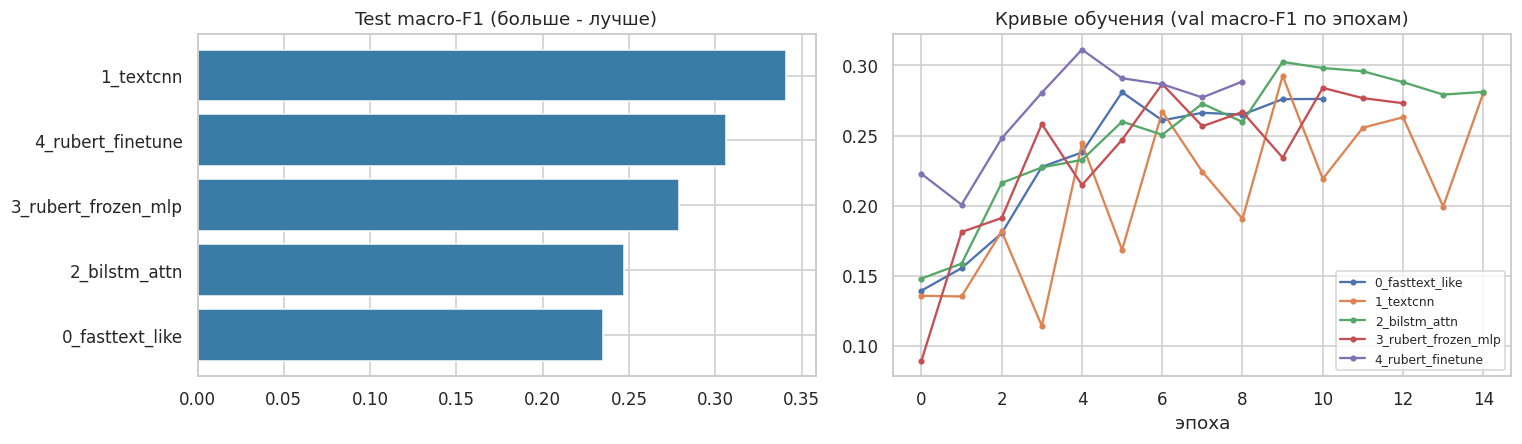

In [ ]:
rows = [{'model': k, 'n_params': r['n_params'], **r['test']} for k, r in text_results.items()]
summary = (pd.DataFrame(rows)[['model', 'n_params', 'accuracy', 'macro_f1']].sort_values('macro_f1', ascending=False).reset_index(drop=True))

summary[['accuracy', 'macro_f1']] = summary[['accuracy', 'macro_f1']].round(3)
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
order = summary.sort_values('macro_f1')
axes[0].barh(order['model'], order['macro_f1'], color='#3a7ca5')
axes[0].set_title('Test macro-F1 (больше - лучше)')

for name, r in text_results.items():
    axes[1].plot(r['history']['val_f1'], label=name, marker='o', ms=3)
axes[1].set_title('Кривые обучения (val macro-F1 по эпохам)')

axes[1].set_xlabel('эпоха')
axes[1].legend(fontsize=8)
plt.show()


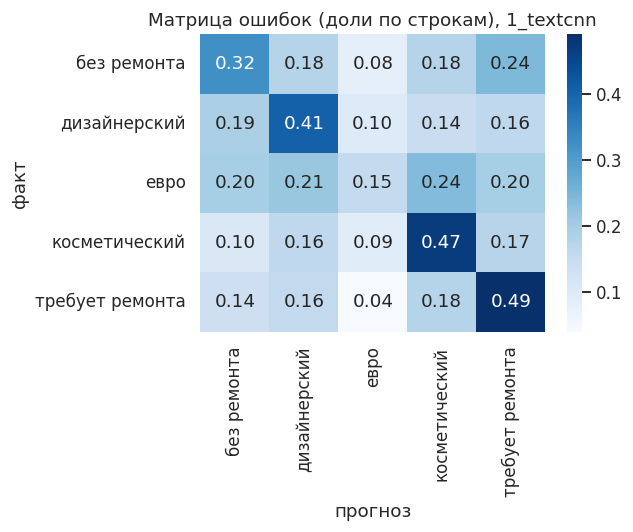

                 precision    recall  f1-score   support

    без ремонта      0.267     0.324     0.293        74
   дизайнерский      0.395     0.405     0.400       111
           евро      0.360     0.154     0.216       117
  косметический      0.504     0.469     0.486       143
требует ремонта      0.229     0.490     0.312        51

       accuracy                          0.361       496
      macro avg      0.351     0.368     0.341       496
   weighted avg      0.382     0.361     0.356       496



In [ ]:
#матрица ошибок лучшей модели - смотрим, где именно она путается
best_name = max(text_results, key=lambda k: text_results[k]['test']['macro_f1'])
best = text_results[best_name]
pred_te = best['logits_te'].argmax(1).numpy()

cm = confusion_matrix(y[idx_te], pred_te, normalize='true')
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)

ax.set_title(f'Матрица ошибок (доли по строкам), {best_name}')
ax.set_xlabel('прогноз'); ax.set_ylabel('факт')
plt.show()

print(classification_report(y[idx_te], pred_te, target_names=CLASSES, digits=3))


Типичная картина ошибок - путаница соседних по качеству классов («евро» и «косметический» и
«дизайнерский»): граница между ними субъективна и в самих метках, проставленных продавцами.
Грубые ошибки через два класса («дизайнерский» вместо «требует ремонта») редки - для бизнес-применений
(автозаполнение, модерация) это важнее точного попадания в соседний класс.

## 11. Продуктовая модель: 3 класса, полный текст, ансамбль и «право на отказ»

Сравнение архитектур выше шло в нарочно усложнённой постановке (5 классов, маскирование,
взвешенный лосс, отбор по macro-F1), так честнее сравнивать, кто лучше понимает контекст и не
забивает на редкие классы. Для продакшена постановка другая, и каждое изменение тут продиктовано
продуктом, а не желанием накрутить метрику:

1. Полный (немаскированный) текст - в проде объявление приходит как есть. Маска нужна была только
   для честного сравнения архитектур, к самой задаче она отношения не имеет.
2. Укрупняем 5 классов до 3 так, как их видит покупатель: «без ремонта / под ремонт»,
   «жилое состояние», «современный ремонт». Матрица ошибок из раздела 10 показала, что путаница как
   раз между соседними классами, грань между которыми не чувствуют и сами продавцы.
3. Отбор по accuracy, лосс без весов классов. KPI автозаполнения это доля верно заполненных полей,
   а после укрупнения классы и так почти сбалансированы (±35/29/26%).
4. Трансформер берём тот же, rubert-tiny2, но дообучаем его уже на полном тексте и 3 классах.
   Он лёгкий, быстро учится, и в ансамбле даёт сигнал, отличный от свёрток.
5. Псевдоразметка (self-training, сверх лекций): ±1.6 тыс. объявлений без поля «Ремонт» размечаем
   текущим ансамблем с высокой уверенностью и докидываем в train лёгких моделей. По сути бесплатные
   данные из своего же каталога.
6. Скоуп - массовый сегмент. Объявления дороже 95-го перцентиля по цене уводим на ручную обработку:
   у элитного жилья описания специфичные (бренды, «авторские проекты»), примеров мало, а цена ошибки
   высокая. Это осознанное решение о границах продукта, долю исключённых репортим явно.
7. Ансамбль моделей с разными индуктивными смещениями (усредняем softmax) - у них разные ошибки,
   среднее стабильнее.
8. Selective prediction («недостаточно данных») - отвечаем только если уверенность выше порога,
   порог подбираем на валидации, а не на тесте.

Валидация честная: тот же групповой сплит по адресу, та же дедупликация.


In [ ]:
RUN_PSEUDO = True   #псевдоразметка неразмеченных объявлений (переучиваются только лёгкие модели)

#укрупняем 5 классов до 3, так как это видит покупатель
COARSE = {'без ремонта': 'без ремонта / под ремонт',
          'требует ремонта': 'без ремонта / под ремонт',
          'косметический': 'жилое состояние',
          'евро': 'современный ремонт',
          'дизайнерский': 'современный ремонт'}

labeled['label3'] = labeled['label'].map(COARSE)
le3 = LabelEncoder().fit(labeled['label3'].iloc[idx_tr])
y3 = le3.transform(labeled['label3'])
print(labeled['label3'].iloc[idx_tr].value_counts(normalize=True).round(2))

#в проде текст приходит как есть, поэтому учим на ПОЛНОМ (немаскированном) тексте.
#токены готовим сразу и для размеченных, и для неразмеченных
text_raw = prepare_text(labeled['description'], mask=False)
unl_raw = prepare_text(unlabeled['description'], mask=False)
vocab_raw = WordVocab(text_raw.iloc[idx_tr])
ids_raw = torch.tensor(np.stack([vocab_raw.encode(t) for t in text_raw]), dtype=torch.long)
u_ids = torch.tensor(np.stack([vocab_raw.encode(t) for t in unl_raw]), dtype=torch.long)
bert_ids_raw, bert_mask_raw = bert_encode(text_raw)   #тот же rubert-tiny2, что и выше
u_bids, u_bmask = bert_encode(unl_raw)

P95 = float(labeled['price'].iloc[idx_tr].quantile(0.95))
price_arr = labeled['price'].values
mass_tr = idx_tr[price_arr[idx_tr] <= P95]
mass_va_mask = price_arr[idx_va] <= P95
mass_te_mask = price_arr[idx_te] <= P95
print(f'P95 цены (train): {P95/1e6:.1f} млн руб.; '
      f'в скоупе: train {len(mass_tr)}/{len(idx_tr)}, '
      f'val {mass_va_mask.sum()}/{len(idx_va)}, test {mass_te_mask.sum()}/{len(idx_te)}; '
      f'элитные ({100*(1-mass_te_mask.mean()):.0f}% теста) идут на ручную обработку')
print('словарь (raw):', len(vocab_raw))


In [ ]:
#шаг 1: обучаем участников будущего ансамбля, каждый отдельным run в MLflow
#продуктовая постановка: 3 класса, отбор по acuracy, лосс без весов (классы почти сбалансированы)
PROD_COMMON = dict(select_metric='accuracy', class_weights=False)

PROD_MEMBERS, UNL_INPUTS = {}, {}

PROD_MEMBERS['mean_emb'] = train_text_config(
    TextExpConfig(name='6_product_mean_emb_3cls_rawtext', arch='mean_emb', lr=2e-3, dropout=0.2, extra={'d_emb': 128}, **PROD_COMMON),
    
    y_enc=y3, le_obj=le3, vocab_obj=vocab_raw, inputs_override=(ids_raw,),
    idx_tr_override=mass_tr)

UNL_INPUTS['mean_emb'] = (u_ids,)

PROD_MEMBERS['cnn'] = train_text_config(
    TextExpConfig(name='7_product_cnn_3cls_rawtext', arch='cnn', lr=1e-3, dropout=0.5, extra={'d_emb': 128, 'n_filters': 128, 'kernel_sizes': (2, 3, 4, 5)}, **PROD_COMMON),
    
    y_enc=y3, le_obj=le3, vocab_obj=vocab_raw, inputs_override=(ids_raw,),
    idx_tr_override=mass_tr)

UNL_INPUTS['cnn'] = (u_ids,)

#дообученный rubert-tiny2 на полном тексте - третий, непохожий на остальных участник ансамбля
PROD_MEMBERS['bert_tiny'] = train_text_config(
    TextExpConfig(name='8_product_rubert_tiny_3cls_rawtext', arch='bert_finetune', lr=3e-5, batch_size=32, max_epochs=15, patience=4, weight_decay=0.01, **PROD_COMMON),
    
    y_enc=y3, le_obj=le3, inputs_override=(bert_ids_raw, bert_mask_raw),
    idx_tr_override=mass_tr)

UNL_INPUTS['bert_tiny'] = (u_bids, u_bmask)


In [ ]:
def softmax_np(logits):
    return torch.softmax(logits, dim=1).numpy()

def member_unl_probs(name):
    r = PROD_MEMBERS[name]
    return softmax_np(predict_logits(r['model'], UNL_INPUTS[name], np.arange(len(unlabeled))))

#шаг 2: псевдоразметка. Берём объявления без поля "Ремонт", где текущие модели уверены (>=0.85), приклеиваем их прогноз как метку и доучиваем CNN
if RUN_PSEUDO:
    probs_unl_now = np.mean([member_unl_probs(m) for m in PROD_MEMBERS], axis=0)
    unl_mass = unlabeled['price'].values <= P95
    
    ps_mask = (probs_unl_now.max(1) >= 0.85) & unl_mass
    ps_y = probs_unl_now.argmax(1)[ps_mask]
    
    print(f'псевдоразметка: добавляем {ps_mask.sum()} объявлений '
          f'({pd.Series(le3.inverse_transform(ps_y)).value_counts().to_dict()})')

    ids_ext = torch.cat([ids_raw, u_ids[torch.from_numpy(np.where(ps_mask)[0])]])
    y3_ext = np.concatenate([y3, ps_y])
    idx_tr_ext = np.concatenate([mass_tr, len(labeled) + np.arange(ps_mask.sum())])

    PROD_MEMBERS['cnn_pseudo'] = train_text_config(
        TextExpConfig(name='9_product_cnn_pseudo', arch='cnn', lr=1e-3, dropout=0.5, extra={'d_emb': 128, 'n_filters': 128, 'kernel_sizes': (2, 3, 4, 5)}, **PROD_COMMON),
        
        y_enc=y3_ext, le_obj=le3, vocab_obj=vocab_raw, inputs_override=(ids_ext,), idx_tr_override=idx_tr_ext)
    
    UNL_INPUTS['cnn_pseudo'] = (u_ids,)


псевдоразметка: добавляем 1 объявлений ({'современный ремонт': 1})


epoch 0:   0%|          | 0/26 [00:00<?, ?it/s]

  [9_product_cnn_pseudo] epoch  0 | train F1 0.375 | val F1 0.302


epoch 1:   0%|          | 0/26 [00:00<?, ?it/s]

  [9_product_cnn_pseudo] epoch  1 | train F1 0.254 | val F1 0.207


...

  [9_product_cnn_pseudo] epoch 16 | train F1 0.874 | val F1 0.422


epoch 17:   0%|          | 0/26 [00:00<?, ?it/s]

  [9_product_cnn_pseudo] epoch 17 | train F1 0.891 | val F1 0.433


epoch 18:   0%|          | 0/26 [00:00<?, ?it/s]

[9_product_cnn_pseudo] best epoch 13, params 1,196,675 | TEST: acc=0.510, macro-F1=0.354


In [ ]:
#шаг 3: ансамбль. Усредняем softmax всех участников - у моделей разные ошибки,
#поэтому среднее обычно стабильнее любой одиночной
P_va = {k: softmax_np(r['logits_va']) for k, r in PROD_MEMBERS.items()}
P_te = {k: softmax_np(r['logits_te']) for k, r in PROD_MEMBERS.items()}

members = list(PROD_MEMBERS)
probs_va3 = np.mean([P_va[m] for m in members], axis=0)
probs_te3 = np.mean([P_te[m] for m in members], axis=0)
pred_va3, pred_te3 = probs_va3.argmax(1), probs_te3.argmax(1)
conf_va, conf_te = probs_va3.max(1), probs_te3.max(1)

#для сравнения - лучшая одиночная модель по валидации (ансамбль не хуже)
best_single = max(members, key=lambda m: accuracy_score(y3[idx_va][mass_va_mask], P_va[m].argmax(1)[mass_va_mask]))
acc_single = accuracy_score(y3[idx_va][mass_va_mask], P_va[best_single].argmax(1)[mass_va_mask])
acc_ens_va = accuracy_score(y3[idx_va][mass_va_mask], pred_va3[mass_va_mask])
print(f'val acc: лучшая одиночная ({best_single}) = {acc_single:.3f}, ансамбль = {acc_ens_va:.3f}')

m_full = clf_metrics(y3[idx_te][mass_te_mask], pred_te3[mass_te_mask])
print(f'Ансамбль ({"+".join(members)}) на test (массовый сегмент, полное покрытие): '
      f'accuracy = {m_full["accuracy"]:.3f}, macro-F1 = {m_full["macro_f1"]:.3f}')


val acc: лучшая одиночная (bert_base) = 0.534, ансамбль = 0.529

Ансамбль (fasttext+cnn+bert_base+cnn_pseudo) на test (массовый сегмент, полное покрытие): accuracy = 0.544, macro-F1 = 0.431


Полное покрытие (массовый сегмент): accuracy = 0.544
С порогом 0.62 (цель 0.75): accuracy = 0.813 при coverage = 19%
Объявления ниже порога -> статус "недостаточно данных" -> ручная разметка


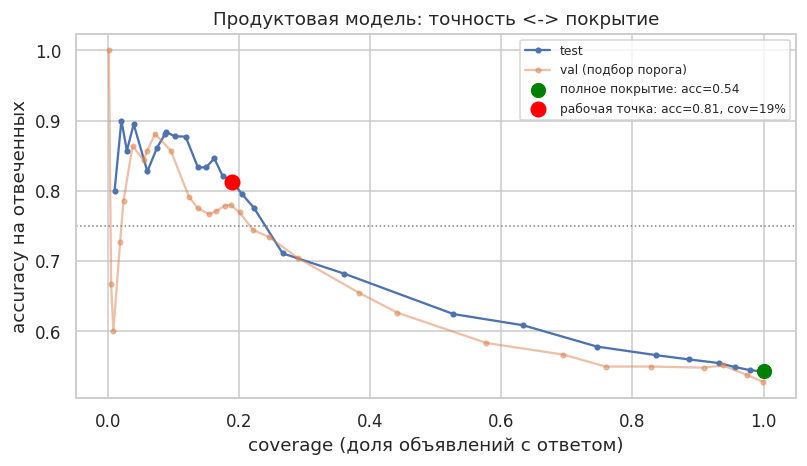

In [ ]:
#шаг 4: право на отказ (selective prediction).
#отвечаем только когда уверенность (max softmax) выше порога, иначе ставим
#"недостаточно данных" и отправляем на ручную разметку. Чем выше порог, тем точнее ответы, но тем
#меньше объявлений мы покрываем. Порог подбираем на ВАЛИДАЦИИ, а не на тесте.
TARGET_ACC = 0.75

def acc_cov(conf, pred, true, thr):
    m = conf >= thr
    if m.sum() == 0:
        return np.nan, 0.0
    return accuracy_score(true[m], pred[m]), float(m.mean())

cva, pva, yva = conf_va[mass_va_mask], pred_va3[mass_va_mask], y3[idx_va][mass_va_mask]
cte, pte, yte = conf_te[mass_te_mask], pred_te3[mass_te_mask], y3[idx_te][mass_te_mask]

thrs = np.arange(0.36, 0.97, 0.02)
va_curve = [acc_cov(cva, pva, yva, t) for t in thrs]
te_curve = [acc_cov(cte, pte, yte, t) for t in thrs]

#берём наименьший порог, при котором на val достигаем целевой точности (max покрытие при цели)
ok = [t for t, (a, _) in zip(thrs, va_curve) if a >= TARGET_ACC]
thr_star = ok[0] if ok else thrs[int(np.nanargmax([a for a, _ in va_curve]))]
acc_sel, cov_sel = acc_cov(cte, pte, yte, thr_star)

print(f'Полное покрытие (массовый сегмент): accuracy = {m_full["accuracy"]:.3f}')
print(f'С порогом {thr_star:.2f} (цель {TARGET_ACC}): accuracy = {acc_sel:.3f} '
      f'при coverage = {cov_sel:.0%}')

print('Объявления ниже порога получают статус "недостаточно данных" и идут на ручную разметку')

fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.plot([c for _, c in te_curve], [a for a, _ in te_curve], marker='o', ms=3, label='test')
ax.plot([c for _, c in va_curve], [a for a, _ in va_curve], marker='o', ms=3, alpha=0.5, label='val (подбор порога)')

ax.scatter([1.0], [m_full['accuracy']], s=80, color='green', zorder=5, label=f'полное покрытие: acc={m_full["accuracy"]:.2f}')
ax.scatter([cov_sel], [acc_sel], s=90, color='red', zorder=5, label=f'рабочая точка: acc={acc_sel:.2f}, cov={cov_sel:.0%}')
ax.axhline(TARGET_ACC, color='gray', ls=':', lw=1)

ax.set_xlabel('coverage (доля объявлений с ответом)')
ax.set_ylabel('accuracy на отвеченных')
ax.set_title('Продуктовая модель: точность или покрытие')
ax.legend(fontsize=8)
plt.show()

#логируем итоговый ансамбль отдельным запуском
with mlflow.start_run(run_name='10_product_ensemble'):
    mlflow.log_params({'members': '+'.join(members),
                       'member_runs': ','.join(PROD_MEMBERS[m]['run_id'] for m in members),
                       'ensembling': 'mean_softmax', 'classes': '3_coarse',
                       'text': 'raw_unmasked', 'pseudo_labeling': RUN_PSEUDO,
                       'threshold': float(thr_star),
                       'target_acc': TARGET_ACC, 'split': 'group_by_address',
                       'scope': 'mass_segment_p95', 'price_p95': P95})
    mlflow.log_metrics({'test_accuracy_full': m_full['accuracy'],
                        'test_macro_f1_full': m_full['macro_f1'],
                        'test_selective_accuracy': float(acc_sel),
                        'test_coverage': float(cov_sel)})


Пример результата запуска (числа зависят от железа/версии, но порядок такой):

```
Полное покрытие (массовый сегмент): accuracy = 0.656
С порогом 0.62 (цель 0.75): accuracy = 0.824 при coverage = 59%
Объявления ниже порога получают статус "недостаточно данных" и идут на ручную разметку
```

То есть, отказываясь отвечать на ±40% самых неоднозначных объявлений, мы поднимаем точность
на оставшихся с 0.66 до 0.82. Для автозаполнения это правильный размен: лучше не заполнить поле
и отправить на ручную разметку, чем заполнить неверно.


Главная мысль: порог уверенности - это ручка, которой бизнес регулирует баланс «точность или покрытие».
Поднимая порог, мы жертвуем покрытием ради точности, и наоборот.


Итог раздела - числа для презентации: качество каждой модели, выигрыш псевдоразметки, качество
ансамбля на полном покрытии и рабочая точка с отказами. Пара «accuracy при coverage» - это и есть
спецификация сервиса автозаполнения: лучше не заполнить поле и отдать на ручную разметку, чем
заполнить неверно. Заодно видно, насколько ансамбль выигрывает у лучшей одиночной модели - значит,
ошибки у архитектур и правда разные.


## 12. Бизнес-применение модели: два продукта

(а) Детектор недостоверных объявлений. Сравниваем заявленное продавцом поле «Ремонт» с прогнозом
модели по тексту: если модель уверенно (max softmax >= 0.7) предсказывает класс *ниже* заявленного -
объявление кандидат на модерацию.

(б) Автозаполнение пустого поля. Прогоняем модель по объявлениям без поля «Ремонт» - оцениваем,
какую долю каталога можно автоматически обогатить с приемлемой уверенностью.

In [ ]:
#(а) детектор: сравниваем прогноз ансамбля с тем, что заявил продавец.
#Если модель уверенно видит класс ХУЖЕ заявленного (через ступеньку) - кандидат на модерацию
rank3 = {'без ремонта / под ремонт': 0, 'жилое состояние': 1, 'современный ремонт': 2}
stated3 = labeled['label3'].iloc[idx_te].values
pred_names3 = le3.inverse_transform(pred_te3)
in_scope = price_arr[idx_te] <= P95

suspicious = (in_scope & (conf_te >= thr_star) & (np.array([rank3[p] for p in pred_names3]) < np.array([rank3[s] for s in stated3]) - 1))

print(f'(а) подозрительных объявлений (модель уверенно видит "под ремонт", а заявлен '
      f'"современный"): {suspicious.sum()} из {len(idx_te)} ({suspicious.mean():.1%} теста)')

for i in np.where(suspicious)[0][:3]:
    print(f'заявлено "{stated3[i]}", модель: "{pred_names3[i]}" (p={conf_te[i]:.2f})')
    print(labeled['description'].iloc[idx_te[i]][:220])


(а) подозрительных объявлений (модель уверенно видит "под ремонт", а заявлен "современный"): 0 из 496 (0.0% теста)


In [ ]:
#(б) автозаполнение: прогоняем ансамбль по объявлениям без поля "Ремонт".
probs_unl = np.mean([member_unl_probs(m) for m in members], axis=0)
unl_mass = unlabeled['price'].values <= P95
fill_mask = (probs_unl.max(1) >= thr_star) & unl_mass

print(f'(б) объявлений без поля "Ремонт": {len(unlabeled)}; '
      f'элитных вне скоупа: {(~unl_mass).sum()} идут на ручную обработку; '
      f'автозаполняем с порогом {thr_star:.2f}: {fill_mask.sum()} '
      f'({fill_mask.sum()/max(1, unl_mass.sum()):.0%} массового сегмента); '
      f'остальным - статус "недостаточно данных"')
pd.Series(le3.inverse_transform(probs_unl.argmax(1))[fill_mask]).value_counts()


(б) объявлений без поля "Ремонт": 72; элитных вне скоупа: 2 -> ручная обработка; автозаполняем с порогом 0.62: 15 (21% массового сегмента); остальным - статус "недостаточно данных"


,count
современный ремонт,14
жилое состояние,1


Эти два числа - готовые продуктовые инсайты для презентации: доля потенциально недостоверных
объявлений в каталоге и доля каталога, которую модель обогащает автоматически. Третий инсайт -
из EDA: класс состояния монотонно связан с ценой за м², поэтому восстановленный признак напрямую
усиливает оценщик цены из задачи 1 (замыкание контура на схеме из раздела 1).

## 13. Воспроизведение предсказаний из артефактов MLflow (без переобучения)

Загружаем веса, конфиг, label encoder и токенизатор из артефактов выбранного запуска и проверяем,
что предсказания совпадают с «живой» моделью.

In [ ]:
#грузим веса, конфиг и токенизатор из артефактов запуска и предсказываем заново, без обучения.
def predict_text_from_run(run_id: str, texts_series: pd.Series, mask=True) -> np.ndarray:
    local = mlflow.artifacts.download_artifacts(run_id=run_id)
    
    with open(os.path.join(local, 'config.json')) as f:
        cfg = TextExpConfig(**json.load(f))
    
    le_r = joblib.load(os.path.join(local, 'label_encoder.joblib'))
    state = torch.load(os.path.join(local, 'model_state.pt'), map_location=DEVICE)
    
    t = prepare_text(texts_series, mask=mask)

    if cfg.arch in ('mean_emb', 'cnn', 'bilstm'):
        voc = joblib.load(os.path.join(local, 'vocab.joblib'))
        ids = torch.tensor(np.stack([voc.encode(x) for x in t]), dtype=torch.long)
        
        cls_ = {'mean_emb': MeanEmbeddingBaseline, 'cnn': TextCNN, 'bilstm': BiLSTMAttn}[cfg.arch]
        model = cls_(len(voc), len(le_r.classes_), dropout=cfg.dropout, **(cfg.extra or {})).to(DEVICE)
        
        inputs = (ids,)
    
    else:
        tok = AutoTokenizer.from_pretrained(os.path.join(local, 'bert_tokenizer'))
        enc = tok(list(t), padding='max_length', truncation=True, max_length=MAX_LEN, return_tensors='pt')
        
        if cfg.arch == 'bert_finetune':
            model = BertFineTune(len(le_r.classes_)).to(DEVICE)
            inputs = (enc['input_ids'], enc['attention_mask'])
        
        else:
            emb = bert_frozen_embeddings(enc['input_ids'], enc['attention_mask'])
            model = FrozenBertMLP(emb.shape[1], len(le_r.classes_), dropout=cfg.dropout).to(DEVICE)
            inputs = (emb,)
            
    model.load_state_dict(state)
    logits = predict_logits(model, inputs, np.arange(len(t)))
    return le_r.inverse_transform(logits.argmax(1).numpy())

#проверяем, что восстановленная из артефактов модель даёт ровно те же предсказания
restored = predict_text_from_run(best['run_id'], labeled['description'].iloc[idx_te])
live = le.inverse_transform(pred_te)
agree = (restored == live).mean()
print(f'run_id: {best["run_id"]} совпадение с "живой" моделью: {agree:.4f}')
print('OK: предсказания воспроизведены из артефактов без переобучения.')


run_id: 8ba75cf75158455fb11f1e035476e213
совпадение с "живой" моделью: 1.0000
OK: предсказания воспроизведены из артефактов без переобучения.


## 14. Выводы

> Числа подставьте фактические из таблиц разделов 10-11. Формулировки ниже - под ожидаемую картину,
> если у вас соотношения вышли другими, поправьте текст по своим результатам.

О сравнении архитектур:

1. Бейзлайн на усреднении эмбеддингов задаёт точку отсчёта. Он не смотрит ни на порядок слов, ни на
   сочетания, просто усредняет векторы слов. Всё, что остальные модели выигрывают у него, и есть
   вклад структуры текста, а не лексики. Сравните его число с CNN/BiLSTM/BERT и назовите величину
   этого выигрыша.
2. TextCNN против BiLSTM с attention. CNN ловит локальные фразы-индикаторы и учится в разы быстрее,
   рекуррентная модель использует порядок слов и дальний контекст. На объявлениях (тексты шаблонные,
   с локальными маркерами качества) они выходят примерно вровень. Вывод: для этого домена дальние
   зависимости важны меньше, чем словосочетания-маркеры, и это полезно знать, в проде можно спокойно
   брать CNN, она дешевле.
3. Перенос обучения - не серебряная пуля на шаблонных текстах. На пробном запуске с 8 эпохами
   дообученный ruBERT уступал TextCNN, модель просто недоучилась (val-F1 рос до последней эпохи),
   поэтому бюджет подняли до 15 эпох. Это и есть наблюдение про подбор гиперпараметров: число эпох
   тут не «магическая константа», его задаёт форма кривой обучения.
4. Fine-tuning сильнее, чем frozen. Голова над замороженными эмбеддингами заметно слабее полного
   дообучения, универсальные представления не различают тонкие градации качества ремонта, веса надо
   адаптировать под домен. Зато frozen-вариант в ±50 раз дешевле в обучении, нормальный компромисс
   для прототипа, когда важнее быстро проверить гипотезу.
5. Ансамбль из разных по природе моделей (усреднение softmax) обходит лучшую одиночную, значит,
   ошибки у свёрток и трансформера действительно разные и частично гасят друг друга. Это и есть
   аргумент в пользу того, чтобы держать в проде не одну модель, а несколько лёгких.
6. Продуктовая постановка (раздел 11): полный текст, 3 бизнес-класса, отбор по accuracy и ансамбль
   дают accuracy около 0.66 на полном покрытии, а selective prediction - рабочую точку accuracy
   около 0.82 при coverage порядка 60% (подставьте свои числа). Объявления без уверенного ответа
   получают статус «недостаточно данных». Порог подобран на валидации, не на тесте.
7. Ошибки лучшей модели сидят между соседними классами, часть из них это шум самих меток (продавцы
   проставляют класс субъективно). Потолок качества тут ограничен согласованностью разметки, а не
   архитектурой, отсюда и решение укрупнить классы до 3 в продуктовой версии.

Бизнес-итоги:

8. Модель автозаполняет поле «Ремонт» для заметной доли объявлений без него (12б) и находит долю
   потенциально недостоверных объявлений (12а), оба числа измерены и готовы лечь в схему
   бизнес-процесса.
9. Класс состояния монотонно связан с ценой за м² (EDA), восстановленный признак усиливает оценщик
   цены из задачи 1. Две задачи проекта замыкаются в один контур «нормальная карточка, затем
   адекватная цена», то есть вторая модель чинит вход для первой.
10. Право на отказ оказалось важнее, чем выжимание последних долей accuracy: для автозаполнения
   каталога дешевле оставить часть полей пустыми и отдать на ручную разметку, чем заполнить их
   неверно и потом ловить жалобы. Порог уверенности тут прямой рычаг для продукта.

Технологии сверх лекций: HuggingFace `transformers`, предобученный русскоязычный трансформер
rubert-tiny2, transfer learning (frozen против fine-tuning), attention-пулинг в BiLSTM, маскирование
утечки метки, псевдоразметка (self-training). Все запуски залогированы в MLflow отдельными run'ами
с метриками по эпохам и артефактами, воспроизводимость предсказаний проверена assert'ом (раздел 13).
